### Exercícios 
Data: 13/03/2026

Nome: Elisa Rachel Beninca Martins

In [14]:
import numpy as np
import pandas as pd

Exercício 1

In [15]:
tempos = [12, 15, 14, 13, 16, 12, 14, 150, 13, 15]

q1 = np.percentile(tempos, 25)
q2 = np.percentile(tempos, 50)
q3 = np.percentile(tempos, 75)

print(f"Q1 (25%): {q1}")
print(f"Q2 (50%): {q2}")
print(f"Q3 (75%): {q3}")

Q1 (25%): 13.0
Q2 (50%): 14.0
Q3 (75%): 15.0


Exercício 2

In [16]:
iqr = q3 - q1
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

print(f"IQR: {iqr}")
print(f"Limite Inferior: {limite_inferior}")
print(f"Limite Superior: {limite_superior}")

IQR: 2.0
Limite Inferior: 10.0
Limite Superior: 18.0


Exercício 3

In [17]:
dados = [100, 150, 200, 250, 300, 350]
n = len(dados)

if n % 2 == 0:
    metade = n // 2
    primeira_metade = dados[:metade]
    segunda_metade = dados[metade:]
else:
    metade = n // 2
    primeira_metade = dados[:metade]
    segunda_metade = dados[metade + 1:]

# Mediana de cada metade
def mediana(lst):
    m = len(lst)
    if m % 2 == 0:
        return (lst[m // 2 - 1] + lst[m // 2]) / 2
    else:
        return lst[m // 2]

q1_manual = mediana(primeira_metade)
q3_manual = mediana(segunda_metade)

print(f"Primeira metade: {primeira_metade}")
print(f"Segunda metade:  {segunda_metade}")
print(f"Q1: {q1_manual}")
print(f"Q3: {q3_manual}")

Primeira metade: [100, 150, 200]
Segunda metade:  [250, 300, 350]
Q1: 150
Q3: 300


Exercício 4

In [18]:
tensoes = [110, 115, 120, 118, 112, 220, 116, 114, 119, 12]

q1_t = np.percentile(tensoes, 25)
q3_t = np.percentile(tensoes, 75)
iqr_t = q3_t - q1_t
lim_inf_t = q1_t - 1.5 * iqr_t
lim_sup_t = q3_t + 1.5 * iqr_t

anomalias = [v for v in tensoes if v < lim_inf_t or v > lim_sup_t]

print(f"Limite Inferior: {lim_inf_t}")
print(f"Limite Superior: {lim_sup_t}")
print(f"Anomalias encontradas: {anomalias}")

Limite Inferior: 103.125
Limite Superior: 128.125
Anomalias encontradas: [220, 12]


Exercício 5

In [19]:
def detectar_anomalias(dados, multiplicador):
    q1 = np.percentile(dados, 25)
    q3 = np.percentile(dados, 75)
    iqr = q3 - q1
    lim_inf = q1 - multiplicador * iqr
    lim_sup = q3 + multiplicador * iqr
    return [v for v in dados if v < lim_inf or v > lim_sup]

Exercício 6

In [20]:
vetor_teste = [45, 50, 55, 60, 48, 52, 51, 98, 49, 53]
resultado = detectar_anomalias(vetor_teste, 1.5)
print(f"Outliers detectados: {resultado}")

Outliers detectados: [98]


Exercício 7

In [21]:
df_maquinas = pd.DataFrame({
    'ID_Maquina': [1, 2, 3, 4, 5],
    'Uso_Memoria_MB': [2048, 2100, 2050, 8192, 2080]
})

q1_mem = df_maquinas['Uso_Memoria_MB'].quantile(0.25)
q3_mem = df_maquinas['Uso_Memoria_MB'].quantile(0.75)
iqr_mem = q3_mem - q1_mem

print(df_maquinas)
print(f"\nQ1: {q1_mem} | Q3: {q3_mem} | IQR: {iqr_mem}")

   ID_Maquina  Uso_Memoria_MB
0           1            2048
1           2            2100
2           3            2050
3           4            8192
4           5            2080

Q1: 2050.0 | Q3: 2100.0 | IQR: 50.0


Exercício 8

In [22]:
lim_inf_mem = q1_mem - 1.5 * iqr_mem
lim_sup_mem = q3_mem + 1.5 * iqr_mem

mask = (df_maquinas['Uso_Memoria_MB'] >= lim_inf_mem) & \
       (df_maquinas['Uso_Memoria_MB'] <= lim_sup_mem)

df_normal = df_maquinas[mask]
print(df_normal)

   ID_Maquina  Uso_Memoria_MB
0           1            2048
1           2            2100
2           3            2050
4           5            2080


Exercício 9

In [23]:
df_temp = pd.DataFrame({'temperatura': [80, 82, 85, 81, 300, 83]})

q1_tmp = np.percentile(df_temp['temperatura'], 25)
q3_tmp = np.percentile(df_temp['temperatura'], 75)
iqr_tmp = q3_tmp - q1_tmp
lim_sup_tmp = q3_tmp + 1.5 * iqr_tmp
lim_inf_tmp = q1_tmp - 1.5 * iqr_tmp

mediana_tmp = df_temp['temperatura'].median()

df_temp['temperatura'] = np.where(
    (df_temp['temperatura'] < lim_inf_tmp) | (df_temp['temperatura'] > lim_sup_tmp),
    mediana_tmp,
    df_temp['temperatura']
)

print(df_temp)

   temperatura
0         80.0
1         82.0
2         85.0
3         81.0
4         82.5
5         83.0


Exercício 10

In [24]:
df_sensores_ex10 = pd.DataFrame({
    'Sensor_ID': ['A','A','A','A','A','B','B','B','B','B'],
    'Valor_Leitura': [10, 12, 11, 13, 100, 200, 210, 205, 198, 500]
})

anomalias_grupos = []

for sensor, grupo in df_sensores_ex10.groupby('Sensor_ID'):
    q1_g = grupo['Valor_Leitura'].quantile(0.25)
    q3_g = grupo['Valor_Leitura'].quantile(0.75)
    iqr_g = q3_g - q1_g
    lim_inf_g = q1_g - 1.5 * iqr_g
    lim_sup_g = q3_g + 1.5 * iqr_g
    
    outliers = grupo[(grupo['Valor_Leitura'] < lim_inf_g) | (grupo['Valor_Leitura'] > lim_sup_g)]
    anomalias_grupos.append(outliers)
    print(f"Sensor {sensor} — Limites: [{lim_inf_g:.2f}, {lim_sup_g:.2f}]")
    print(outliers, "\n")

df_anomalias_grupos = pd.concat(anomalias_grupos)
print("Total de anomalias:")
print(df_anomalias_grupos)

Sensor A — Limites: [8.00, 16.00]
  Sensor_ID  Valor_Leitura
4         A            100 

Sensor B — Limites: [185.00, 225.00]
  Sensor_ID  Valor_Leitura
9         B            500 

Total de anomalias:
  Sensor_ID  Valor_Leitura
4         A            100
9         B            500


Exercício 11

In [25]:
df = pd.read_csv('dados_sensores.csv')

print("Valores NaN por coluna:")
print(df.isna().sum())

df['temperatura_celsius'] = df['temperatura_celsius'].fillna(df['temperatura_celsius'].median())
df['pressao_psi'] = df['pressao_psi'].fillna(df['pressao_psi'].median())

print("\nApós fillna:")
print(df.isna().sum())

Valores NaN por coluna:
id_leitura             0
sensor_id              0
temperatura_celsius    2
pressao_psi            2
dtype: int64

Após fillna:
id_leitura             0
sensor_id              0
temperatura_celsius    0
pressao_psi            0
dtype: int64


Exercício 12

In [26]:
def limites_iqr(serie):
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

li_temp, ls_temp = limites_iqr(df['temperatura_celsius'])
li_pres, ls_pres = limites_iqr(df['pressao_psi'])

print(f"Temperatura — Limites: [{li_temp:.2f}, {ls_temp:.2f}]")
print(f"Pressão     — Limites: [{li_pres:.2f}, {ls_pres:.2f}]")

mask_ok = (
    (df['temperatura_celsius'] >= li_temp) & (df['temperatura_celsius'] <= ls_temp) &
    (df['pressao_psi'] >= li_pres) & (df['pressao_psi'] <= ls_pres)
)

df_validado = df[mask_ok].reset_index(drop=True)

print(f"\nLinhas originais: {len(df)} | Após remoção: {len(df_validado)}")

df_validado.to_csv('dados_validados.csv', index=False)
print("Arquivo 'dados_validados.csv' exportado com sucesso!")

Temperatura — Limites: [30.49, 40.13]
Pressão     — Limites: [87.37, 114.89]

Linhas originais: 100 | Após remoção: 95
Arquivo 'dados_validados.csv' exportado com sucesso!


Exercício 13

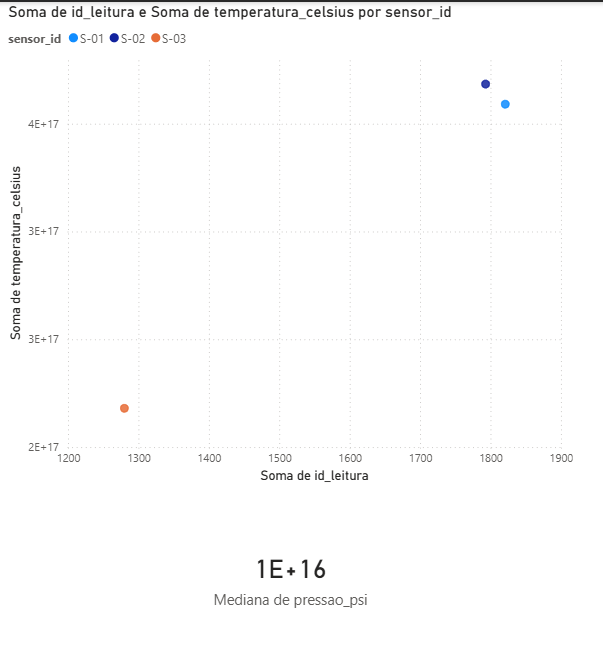